# CityLearn System Identification Notebook

This notebook builds a control-oriented system identification (SID) pipeline for the Annex 96 CE1 TX CityLearn environment.

Main goal:

1. Run CityLearn simulations with randomized control actions.
2. Collect trajectories from the true CityLearn simulator.
3. Train data-driven SID models for building dynamics.
4. Compare SID predictions against the real CityLearn rollout.
5. Report numerical metrics and plots.

The first target is **per-building indoor temperature dynamics**:

$$T_{k+1} = f(T_k, u^{cool}_k, u^{bat}_k, w_k, \ldots)$$

Weather/time/load variables are treated as known exogenous inputs. Battery dynamics and many load balance variables should not be blindly learned if they are already deterministic in the environment.

## 0. Setup

Run this notebook from the repository root, or edit `REPO_DIR` manually. The repository root must contain the local `citylearn/` folder and the dataset folder.

Do **not** use `pip install citylearn`; use the local CE1 CityLearn folder.

In [2]:
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
REPO_DIR = None  # edit manually if needed

if REPO_DIR is None:
    for p in [HERE] + list(HERE.parents):
        if (p / "citylearn").exists():
            REPO_DIR = p
            break

if REPO_DIR is None:
    raise FileNotFoundError("Could not find a folder containing citylearn/. Set REPO_DIR manually.")

sys.path.insert(0, str(REPO_DIR))
from citylearn.citylearn import CityLearnEnv

CLIMATE = "TX"
DATASET_DIR = REPO_DIR / "data" / "datasets" / f"annex96_ce1_{CLIMATE.lower()}_neighborhood"
SCHEMA_PATH = DATASET_DIR / "schema.json"

if not SCHEMA_PATH.exists():
    alt = REPO_DIR / f"annex96_ce1_{CLIMATE.lower()}_neighborhood" / "schema.json"
    if alt.exists():
        SCHEMA_PATH = alt
        DATASET_DIR = alt.parent

print("citylearn loaded from:", __import__('citylearn').__file__)
print("REPO_DIR:", REPO_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("SCHEMA_PATH exists:", SCHEMA_PATH.exists())

citylearn loaded from: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\citylearn\__init__.py
REPO_DIR: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1
DATASET_DIR: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\data\datasets\annex96_ce1_tx_neighborhood
SCHEMA_PATH exists: True


## 1. Inspect the environment

This checks what is controlled and observed. For this CE1 TX case, each building normally has two active actions: `electrical_storage` and `cooling_device`.

The LSTM inside CityLearn mainly updates `indoor_dry_bulb_temperature`; many other observations come from files or algebraic/physics-based update equations.

In [5]:
def make_env(central_agent=False):
    return CityLearnEnv(schema=str(SCHEMA_PATH), root_directory=str(DATASET_DIR), central_agent=central_agent)

env = make_env(central_agent=False)
obs, info = env.reset()

print("Number of buildings:", len(env.buildings))
print(
    "Simulation start/end:",
    env.episode_tracker.simulation_start_time_step,
    env.episode_tracker.simulation_end_time_step
)
print("Episode time steps:", env.time_steps)
print("First building:", env.buildings[0].name)
print("Action names for building 0:", env.action_names[0])
print("Observation names for building 0:")
for i, name in enumerate(env.observation_names[0]):
    print(f"  {i:02d}: {name}")

b0 = env.buildings[0]
print("Building class:", type(b0))
if hasattr(b0, "dynamics"):
    print("Dynamics class:", type(b0.dynamics))
    print("LSTM lookback:", getattr(b0.dynamics, "lookback", None))
    print("LSTM input names:", getattr(b0.dynamics, "input_observation_names", None))

Number of buildings: 25
Simulation start/end: 3624 4343
Episode time steps: 720
First building: resstock-amy2018-2021-release-1-6887
Action names for building 0: ['electrical_storage', 'cooling_device']
Observation names for building 0:
  00: month
  01: hour
  02: outdoor_dry_bulb_temperature
  03: direct_solar_irradiance
  04: outdoor_dry_bulb_temperature_predicted_1
  05: outdoor_dry_bulb_temperature_predicted_2
  06: outdoor_dry_bulb_temperature_predicted_3
  07: direct_solar_irradiance_predicted_1
  08: direct_solar_irradiance_predicted_2
  09: direct_solar_irradiance_predicted_3
  10: indoor_dry_bulb_temperature
  11: non_shiftable_load
  12: dhw_demand
  13: cooling_demand
  14: heating_demand
  15: solar_generation
  16: indoor_dry_bulb_temperature_cooling_set_point
  17: indoor_dry_bulb_temperature_heating_set_point
  18: comfort_band
  19: indoor_dry_bulb_temperature_cooling_delta
  20: indoor_dry_bulb_temperature_heating_delta
  21: hvac_mode
  22: power_outage
  23: electri

## 2. Define observation/action helpers

CityLearn decentralized mode returns observations and actions per building:

```python
obs[building_id][observation_index]
actions[building_id] = [electrical_storage_action, cooling_device_action]
```

The helpers below make extraction less error-prone.

In [6]:
def build_name_to_index(names):
    return {name: i for i, name in enumerate(names)}

obs_index = [build_name_to_index(names) for names in env.observation_names]
action_index = [build_name_to_index(names) for names in env.action_names]

def get_obs_value(obs, building_id, name, default=np.nan):
    idx = obs_index[building_id].get(name)
    if idx is None:
        return default
    return float(obs[building_id][idx])

def get_action_value(actions, building_id, name, default=0.0):
    idx = action_index[building_id].get(name)
    if idx is None:
        return default
    return float(actions[building_id][idx])

def clipped_random_actions(env, rng, cooling_probability=0.80, battery_probability=0.80):
    # Generate random but bounded actions using actual CityLearn action bounds.
    actions = []
    for b, space in enumerate(env.action_space):
        low = np.asarray(space.low, dtype=float)
        high = np.asarray(space.high, dtype=float)
        names = env.action_names[b]
        a = np.zeros(len(names), dtype=float)

        for j, name in enumerate(names):
            if name == "cooling_device":
                a[j] = rng.uniform(low[j], high[j]) if rng.random() < cooling_probability else 0.0
            elif name == "electrical_storage":
                a[j] = rng.uniform(low[j], high[j]) if rng.random() < battery_probability else 0.0
            else:
                a[j] = rng.uniform(low[j], high[j])

        actions.append(a.tolist())
    return actions

## 3. Collect rollout data from CityLearn

We collect transitions of the form:

$$(o_k, a_k, o_{k+1})$$

For each building and timestep, the table stores current observations, actions, and selected next-step targets.

Use `n_rollouts > 1` to collect multiple trajectories under different random action sequences.

In [7]:
BASE_FEATURES = [
    "month", "hour",
    "outdoor_dry_bulb_temperature", "direct_solar_irradiance",
    "outdoor_dry_bulb_temperature_predicted_1", "outdoor_dry_bulb_temperature_predicted_2", "outdoor_dry_bulb_temperature_predicted_3",
    "direct_solar_irradiance_predicted_1", "direct_solar_irradiance_predicted_2", "direct_solar_irradiance_predicted_3",
    "indoor_dry_bulb_temperature",
    "non_shiftable_load", "dhw_demand", "cooling_demand", "heating_demand", "solar_generation",
    "indoor_dry_bulb_temperature_cooling_set_point",
    "indoor_dry_bulb_temperature_heating_set_point",
    "comfort_band", "hvac_mode", "electrical_storage_soc", "net_electricity_consumption",
]

ACTION_FEATURES = ["electrical_storage", "cooling_device"]

TARGETS = [
    "indoor_dry_bulb_temperature",
    "cooling_demand",
    "cooling_electricity_consumption",
    "electrical_storage_soc",
    "net_electricity_consumption",
]

def collect_random_rollouts(n_rollouts=5, seed=42, max_steps=None):
    rng = np.random.default_rng(seed)
    rows = []

    for rollout in range(n_rollouts):
        env = make_env(central_agent=False)
        obs, info = env.reset()
        step = 0

        while not env.terminated:
            actions = clipped_random_actions(env, rng)
            next_obs, reward, terminated, truncated, info = env.step(actions)

            for b in range(len(env.buildings)):
                row = {"rollout": rollout, "t": step, "building_id": b, "building_name": env.buildings[b].name}

                for name in BASE_FEATURES:
                    row[name] = get_obs_value(obs, b, name)
                for name in ACTION_FEATURES:
                    row[f"action_{name}"] = get_action_value(actions, b, name)
                for name in TARGETS:
                    row[f"next_{name}"] = get_obs_value(next_obs, b, name)

                rows.append(row)

            obs = next_obs
            step += 1

            if terminated or truncated:
                break
            if max_steps is not None and step >= max_steps:
                break

        print(f"Collected rollout {rollout+1}/{n_rollouts}: {step} steps")

    return pd.DataFrame(rows)

# For a fast first run, use n_rollouts=3. Increase to 20+ for better SID.
data = collect_random_rollouts(n_rollouts=5, seed=7)
print(data.shape)
display(data.head())

Collected rollout 1/5: 719 steps
Collected rollout 2/5: 719 steps
Collected rollout 3/5: 719 steps
Collected rollout 4/5: 719 steps
Collected rollout 5/5: 719 steps
(89875, 33)


,rollout,t,building_id,building_name,month,hour,outdoor_dry_bulb_temperature,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,...,hvac_mode,electrical_storage_soc,net_electricity_consumption,action_electrical_storage,action_cooling_device,next_indoor_dry_bulb_temperature,next_cooling_demand,next_cooling_electricity_consumption,next_electrical_storage_soc,next_net_electricity_consumption
0,0,0,0,resstock-amy2018-2021-release-1-6887,6.0,1.0,25.4,0.0,25.312054,33.776115,...,3.0,0.0,1.219480,0.132405,0.225207,21.777779,2.944917,0.688423,0.129861,3.155929
1,0,0,1,resstock-amy2018-2021-release-1-123182,6.0,1.0,25.4,0.0,25.312054,33.776115,...,3.0,0.0,0.761215,0.186777,0.821228,23.888889,1.579427,0.342834,0.182893,2.462097
2,0,0,2,resstock-amy2018-2021-release-1-155572,6.0,1.0,25.4,0.0,25.312054,33.776115,...,3.0,0.0,0.853040,-0.017743,0.278426,27.222221,1.412993,0.398927,0.000000,0.762823
3,0,0,3,resstock-amy2018-2021-release-1-20687,6.0,1.0,25.4,0.0,25.312054,33.776115,...,3.0,0.0,0.633216,-0.054924,0.553497,24.444445,1.162535,0.319002,0.000000,0.600196
4,0,0,4,resstock-amy2018-2021-release-1-21356,6.0,1.0,25.4,0.0,25.312054,33.776115,...,3.0,0.0,2.497107,0.000000,0.622179,23.913359,9.210571,2.104108,0.000000,2.923626


## 4. Feature engineering: NARX-style lagged model

A basic one-step model only uses current values. For dynamics, a better structure is NARX-like:

$$T_{k+1} = f(T_k, T_{k-1}, \ldots, u_k, u_{k-1}, \ldots, w_k)$$

The function below adds lags per rollout and building.

In [8]:
def add_lags(df, columns, lags=(1, 2, 3)):
    df = df.sort_values(["rollout", "building_id", "t"]).copy()
    group = df.groupby(["rollout", "building_id"], sort=False)
    for col in columns:
        for lag in lags:
            df[f"{col}_lag{lag}"] = group[col].shift(lag)
    return df

LAG_COLUMNS = [
    "indoor_dry_bulb_temperature",
    "cooling_demand", "heating_demand", "net_electricity_consumption", "electrical_storage_soc",
    "action_cooling_device", "action_electrical_storage",
]

data_lagged = add_lags(data, LAG_COLUMNS, lags=(1, 2, 3))
data_lagged = data_lagged.dropna().reset_index(drop=True)
print(data_lagged.shape)
display(data_lagged.head())

(89500, 54)


,rollout,t,building_id,building_name,month,hour,outdoor_dry_bulb_temperature,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,...,net_electricity_consumption_lag3,electrical_storage_soc_lag1,electrical_storage_soc_lag2,electrical_storage_soc_lag3,action_cooling_device_lag1,action_cooling_device_lag2,action_cooling_device_lag3,action_electrical_storage_lag1,action_electrical_storage_lag2,action_electrical_storage_lag3
0,0,3,0,resstock-amy2018-2021-release-1-6887,6.0,4.0,25.600000,0.0,29.644865,37.230541,...,1.219480,0.128908,0.129861,0.000000,0.000000,0.547635,0.225207,0.000000,0.000000,0.132405
1,0,4,0,resstock-amy2018-2021-release-1-6887,6.0,5.0,25.600000,0.0,31.909439,36.070450,...,3.155929,0.127963,0.128908,0.129861,0.710882,0.000000,0.547635,0.127974,0.000000,0.000000
2,0,5,0,resstock-amy2018-2021-release-1-6887,6.0,6.0,25.000000,0.0,34.119072,36.074654,...,1.148680,0.252470,0.127963,0.128908,0.628534,0.710882,0.000000,-0.072349,0.127974,0.000000
3,0,6,0,resstock-amy2018-2021-release-1-6887,6.0,7.0,25.600000,169.5,34.639614,34.419163,...,1.112568,0.175163,0.252470,0.127963,0.641828,0.628534,0.710882,0.000000,-0.072349,0.127974
4,0,7,0,resstock-amy2018-2021-release-1-6887,6.0,8.0,26.700001,2.0,35.420773,32.411674,...,2.992347,0.173879,0.175163,0.252470,0.257008,0.641828,0.628534,0.083419,0.000000,-0.072349


## 5. Train/test split

We split by rollout, not by random rows. This is stricter and avoids leakage between adjacent timesteps.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

all_rollouts = sorted(data_lagged["rollout"].unique())
train_rollouts, test_rollouts = train_test_split(all_rollouts, test_size=0.30, random_state=0)
train_df = data_lagged[data_lagged["rollout"].isin(train_rollouts)].copy()
test_df = data_lagged[data_lagged["rollout"].isin(test_rollouts)].copy()

print("Train rollouts:", train_rollouts)
print("Test rollouts:", test_rollouts)
print("Train rows:", len(train_df), "Test rows:", len(test_df))

Train rollouts: [1, 3, 4]
Test rollouts: [2, 0]
Train rows: 53700 Test rows: 35800


## 6. Model 1: Linear NARX/Ridge baseline

This is the control-engineering baseline. It is interpretable, fast, and MPC-friendly.

In [10]:
FEATURE_COLUMNS = [
    "month", "hour",
    "outdoor_dry_bulb_temperature", "direct_solar_irradiance",
    "outdoor_dry_bulb_temperature_predicted_1", "outdoor_dry_bulb_temperature_predicted_2", "outdoor_dry_bulb_temperature_predicted_3",
    "direct_solar_irradiance_predicted_1", "direct_solar_irradiance_predicted_2", "direct_solar_irradiance_predicted_3",
    "indoor_dry_bulb_temperature",
    "non_shiftable_load", "dhw_demand", "cooling_demand", "heating_demand", "solar_generation",
    "indoor_dry_bulb_temperature_cooling_set_point", "indoor_dry_bulb_temperature_heating_set_point",
    "comfort_band", "hvac_mode", "electrical_storage_soc", "net_electricity_consumption",
    "action_electrical_storage", "action_cooling_device",
]
FEATURE_COLUMNS += [c for c in data_lagged.columns if c.endswith("_lag1") or c.endswith("_lag2") or c.endswith("_lag3")]
TARGET_COLUMN = "next_indoor_dry_bulb_temperature"

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

ridge_model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

## 7. Model 2: Nonlinear MLP NARX model

This is the first neural system identification model. It is still simpler than an LSTM because it uses explicit lagged features.

In [11]:
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=0,
        verbose=False,
    )),
])
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

## 8. Metrics

We evaluate one-step prediction first. For control/MPC, one-step accuracy is not enough, but it is a useful initial check.

In [12]:
def regression_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cvrmse = rmse / max(np.mean(np.abs(y_true)), 1e-9) * 100.0
    nmbe = np.mean(y_pred - y_true) / max(np.mean(np.abs(y_true)), 1e-9) * 100.0
    return {"model": label, "RMSE [degC]": rmse, "MAE [degC]": mae, "R2": r2, "CVRMSE [%]": cvrmse, "NMBE [%]": nmbe}

metrics_df = pd.DataFrame([
    regression_metrics(y_test, y_pred_ridge, "Linear NARX / Ridge"),
    regression_metrics(y_test, y_pred_mlp, "MLP NARX"),
])
display(metrics_df)

,model,RMSE [degC],MAE [degC],R2,CVRMSE [%],NMBE [%]
0,Linear NARX / Ridge,1.322300,0.928372,0.909497,6.677091,-0.021427
1,MLP NARX,0.816131,0.551606,0.965523,4.121140,-0.152292


## 9. True vs predicted plot

This plot uses test samples. It does not yet show recursive rollout behavior.

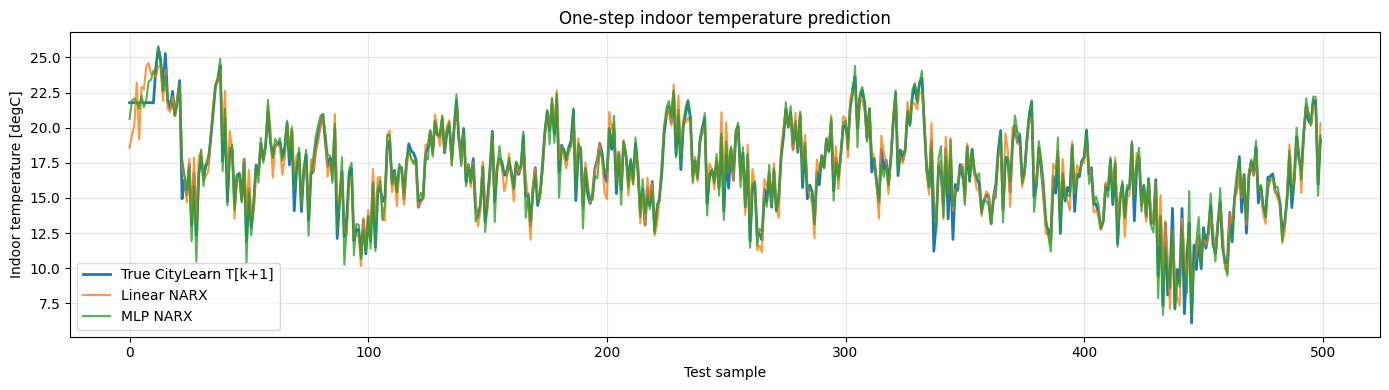

In [13]:
plot_n = min(500, len(y_test))
plt.figure(figsize=(14, 4))
plt.plot(np.asarray(y_test)[:plot_n], label="True CityLearn T[k+1]", linewidth=2)
plt.plot(y_pred_ridge[:plot_n], label="Linear NARX", alpha=0.8)
plt.plot(y_pred_mlp[:plot_n], label="MLP NARX", alpha=0.8)
plt.ylabel("Indoor temperature [degC]")
plt.xlabel("Test sample")
plt.title("One-step indoor temperature prediction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Per-building one-step scores

This shows whether the SID model works uniformly across the 25 buildings or only on average.

In [14]:
rows = []
for b_id, g in test_df.groupby("building_id"):
    Xg = g[FEATURE_COLUMNS]
    yg = g[TARGET_COLUMN]
    rows.append(regression_metrics(yg, ridge_model.predict(Xg), f"B{b_id:02d} Ridge"))
    rows[-1]["building_id"] = b_id
    rows.append(regression_metrics(yg, mlp_model.predict(Xg), f"B{b_id:02d} MLP"))
    rows[-1]["building_id"] = b_id

per_building = pd.DataFrame(rows)
display(per_building.pivot(index="building_id", columns="model", values="RMSE [degC]").head())
summary = per_building.groupby(per_building["model"].str.extract(r"(Ridge|MLP)")[0])["RMSE [degC]"].describe()
display(summary)

model,B00 MLP,B00 Ridge,B01 MLP,B01 Ridge,B02 MLP,B02 Ridge,B03 MLP,B03 Ridge,B04 MLP,B04 Ridge,...,B20 MLP,B20 Ridge,B21 MLP,B21 Ridge,B22 MLP,B22 Ridge,B23 MLP,B23 Ridge,B24 MLP,B24 Ridge
building_id,,,,,,,,,,,,,,,,,,,,,
0,0.60965,0.861294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,0.657982,1.027636,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,0.83254,1.302544,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,1.012892,1.404379,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.887441,1.290753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
MLP,25.0,0.785530,0.225954,0.507949,0.607888,0.707568,0.875047,1.357270
Ridge,25.0,1.239402,0.470328,0.790905,0.937555,1.187935,1.290753,3.134007


## 11. Recursive rollout evaluation for temperature

This is more important for MPC. A model can have good one-step prediction but drift when recursively simulated.

Here we take one test rollout/building and recursively feed the predicted temperature back into lagged temperature features. Exogenous variables and actions remain the same as in the CityLearn rollout.

,model,RMSE [degC],MAE [degC],R2,CVRMSE [%],NMBE [%]
0,Recursive Ridge,2.604243,2.051711,0.245814,15.158926,10.023065
1,Recursive MLP,1.978391,1.425183,0.564749,11.515932,-0.427125


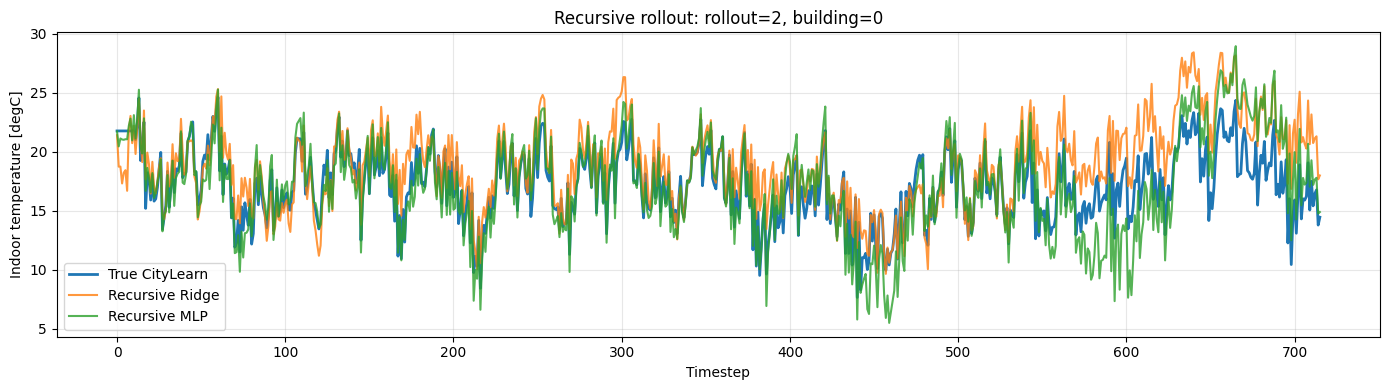

In [15]:
def recursive_temperature_rollout(model, df_rollout_building, feature_columns, target_column):
    df = df_rollout_building.sort_values("t").copy().reset_index(drop=True)
    pred = []
    true = df[target_column].to_numpy(dtype=float)
    temp_history = [
        float(df.loc[0, "indoor_dry_bulb_temperature"]),
        float(df.loc[0, "indoor_dry_bulb_temperature_lag1"]),
        float(df.loc[0, "indoor_dry_bulb_temperature_lag2"]),
        float(df.loc[0, "indoor_dry_bulb_temperature_lag3"]),
    ]
    for i in range(len(df)):
        row = df.iloc[i].copy()
        row["indoor_dry_bulb_temperature"] = temp_history[0]
        row["indoor_dry_bulb_temperature_lag1"] = temp_history[1]
        row["indoor_dry_bulb_temperature_lag2"] = temp_history[2]
        row["indoor_dry_bulb_temperature_lag3"] = temp_history[3]
        X = pd.DataFrame([row[feature_columns].to_dict()])
        yhat = float(model.predict(X)[0])
        pred.append(yhat)
        temp_history = [yhat, temp_history[0], temp_history[1], temp_history[2]]
    return true, np.asarray(pred)

example_rollout = test_rollouts[0]
example_building = 0
example_df = test_df[(test_df["rollout"] == example_rollout) & (test_df["building_id"] == example_building)].copy()
true_ridge, pred_ridge_roll = recursive_temperature_rollout(ridge_model, example_df, FEATURE_COLUMNS, TARGET_COLUMN)
true_mlp, pred_mlp_roll = recursive_temperature_rollout(mlp_model, example_df, FEATURE_COLUMNS, TARGET_COLUMN)

rollout_metrics = pd.DataFrame([
    regression_metrics(true_ridge, pred_ridge_roll, "Recursive Ridge"),
    regression_metrics(true_mlp, pred_mlp_roll, "Recursive MLP"),
])
display(rollout_metrics)

plt.figure(figsize=(14, 4))
plt.plot(true_ridge, label="True CityLearn", linewidth=2)
plt.plot(pred_ridge_roll, label="Recursive Ridge", alpha=0.8)
plt.plot(pred_mlp_roll, label="Recursive MLP", alpha=0.8)
plt.ylabel("Indoor temperature [degC]")
plt.xlabel("Timestep")
plt.title(f"Recursive rollout: rollout={example_rollout}, building={example_building}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Optional: train one model per building

A global model learns shared structure across all buildings. A per-building model may be more accurate because each building has unique thermal behavior.

In [16]:
per_building_models = {}
per_building_rows = []
for b_id in sorted(train_df["building_id"].unique()):
    tr = train_df[train_df["building_id"] == b_id]
    te = test_df[test_df["building_id"] == b_id]
    model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
    model.fit(tr[FEATURE_COLUMNS], tr[TARGET_COLUMN])
    pred = model.predict(te[FEATURE_COLUMNS])
    per_building_models[b_id] = model
    m = regression_metrics(te[TARGET_COLUMN], pred, "Per-building Ridge")
    m["building_id"] = b_id
    per_building_rows.append(m)

per_building_ridge_scores = pd.DataFrame(per_building_rows)
display(per_building_ridge_scores)
print("Average per-building Ridge RMSE:", per_building_ridge_scores["RMSE [degC]"].mean())

,model,RMSE [degC],MAE [degC],R2,CVRMSE [%],NMBE [%],building_id
0,Per-building Ridge,0.782703,0.587988,0.934286,4.529326,-0.168622,0
1,Per-building Ridge,0.911045,0.690342,0.941864,4.448606,0.136109,1
2,Per-building Ridge,1.161735,0.884519,0.939191,4.657644,-0.017264,2
3,Per-building Ridge,1.207349,0.893757,0.931929,6.310558,-0.300676,3
4,Per-building Ridge,1.191232,0.872135,0.924060,7.455634,-0.066260,4
5,Per-building Ridge,0.680830,0.532951,0.909374,3.453391,0.005048,5
6,Per-building Ridge,1.118422,0.837893,0.861816,4.785659,0.200809,6
7,Per-building Ridge,1.894151,1.479270,0.876352,11.614926,-0.370980,7
8,Per-building Ridge,0.642577,0.468168,0.917184,2.980835,0.088633,8
9,Per-building Ridge,1.177328,0.898739,0.910004,6.803254,0.149810,9


Average per-building Ridge RMSE: 0.9487043622311266


## 13. Optional: residual nonlinear model

Course-aligned hybrid approach:

$$T_{k+1} = f_{linear}(\phi_k) + f_{NN}(\phi_k)$$

Instead of asking the NN to learn everything, first fit a linear model and then train an MLP on the residual.

In [17]:
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)
residual_train = y_train.to_numpy() - ridge_train_pred

residual_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=1,
    )),
])
residual_mlp.fit(X_train, residual_train)
resid_test_pred = residual_mlp.predict(X_test)
hybrid_pred = ridge_test_pred + resid_test_pred

hybrid_metrics = pd.DataFrame([
    regression_metrics(y_test, y_pred_ridge, "Linear NARX / Ridge"),
    regression_metrics(y_test, y_pred_mlp, "MLP NARX"),
    regression_metrics(y_test, hybrid_pred, "Ridge + MLP residual"),
])
display(hybrid_metrics)

,model,RMSE [degC],MAE [degC],R2,CVRMSE [%],NMBE [%]
0,Linear NARX / Ridge,1.322300,0.928372,0.909497,6.677091,-0.021427
1,MLP NARX,0.816131,0.551606,0.965523,4.121140,-0.152292
2,Ridge + MLP residual,0.766490,0.515930,0.969590,3.870471,-0.059385


## 14. Save models and dataset

This saves the collected dataset and trained models for reuse in MPC experiments.

In [20]:
import joblib
SAVE_DIR = REPO_DIR / "System Identification" / "sid_results"
SAVE_DIR.mkdir(exist_ok=True)

data_lagged.to_parquet(SAVE_DIR / "citylearn_sid_dataset.parquet", index=False)
joblib.dump(ridge_model, SAVE_DIR / "ridge_narx_temperature_model.joblib")
joblib.dump(mlp_model, SAVE_DIR / "mlp_narx_temperature_model.joblib")
joblib.dump(residual_mlp, SAVE_DIR / "residual_mlp_temperature_model.joblib")
with open(SAVE_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)
print("Saved to:", SAVE_DIR)

Saved to: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\System Identification\sid_results


## 15. Interpretation checklist

Use the metrics as follows:

- Low one-step RMSE means the supervised SID fit is good.
- Low recursive rollout RMSE means the model is actually useful for MPC.
- If one-step is good but rollout is bad, the model suffers from simulation drift.
- If global model is weak but per-building model is good, building-specific dynamics matter.
- If residual hybrid improves over Ridge and MLP, the course-style linear + nonlinear residual structure is useful.

Recommended next step:

1. Train the thermal model on many random rollouts.
2. Keep battery SOC equations analytical.
3. Keep net electricity as an algebraic balance as much as possible.
4. Use the learned thermal model inside MPC.